Département de génie électrique - Polytechnique Montréal

Analyse des signaux - ELE2700

TP4 version 4.0: A2025

---
Numéro d'équipe: #102

Noms, prénoms et matricules:

- Machraoui, Simon : 2487824

- Beaumier, Édouard : 2087482


>⚠ **Attention:**
>
> Avant de commencer à utiliser le `notebook`, assurez-vous de le sauvegarder dans votre Google drive personnel.
>


#$\color{#18a2f2}{\textbf{TP4 - Introduction à la détection radar}}$


##$\color{#a618f2}{\textbf{Mise en contexte:}}$

 Les radars sont des systèmes de détection d'objets fournissant la distance et la vitesse de déplacement d'un objet inconnu visé. Ce TP fera l'étude particulière des radar dits passifs.

 Un radar passif est un équipement qui ne transmet pas de signal radio, il détecte plutôt le passage de signaux d'intérêts en les comparant à un signal de référence. Nous utilisons alors l'opération d'inter-corrélation afin de déterminer si le signal reçu par le radar correspond au signal d'intérêt. Les applications varient, allant de la diffusion télévisée en direct, aux systèmes d'écoute et de surveillance militaires.

 L'avantage de ce type de radar face à un radar conventionnel est sa discrétion (sa présence n'est pas détectable par d'autres radars) ainsi que sa simplicité (seule l'étape de réception est requise, réduisant les coûts et la complexité du système).

 Voici un diagramme bloc général du fonctionnement du radar :

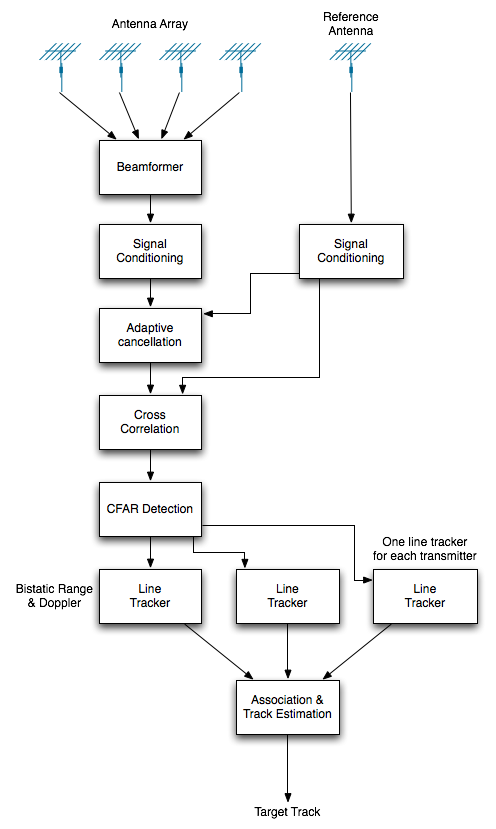

***Image tirée de : https://en.wikipedia.org/wiki/File:PassiveRadarSchematic.png***

Nous allons dans le cadre de ce TP nous concentrer sur l'étude du bloc d'intercorrélation.


# <font color='green'>  Fonctionnement de l'inter-corrélation </font>

L'inter-corrélation est une opération mathématique définie par l'expression suivante :


$$
\begin{align*}
  f(t) \star g(t) &= \int_{-\infty}^{+\infty} f(\tau)g(t+\tau)^* \,\mathrm{d}\tau.
\end{align*}
$$

Lors d'une inter-corrélation, deux fonctions, $f(t)$ et $g(t)$, sont comparées. Afin d'avoir l'intuition derrière cette opération, il faut tout d'abord considérer le produit des fonctions $f(\tau)g(t+\tau)$. Nous avons vu en classe que $g(t+\tau)$ n'est en réalité qu'un décalage de la fonction $g(\tau)$ vers la gauche (si $t$ est positif) ou vers la droite (si $t$ est négatif) lorsque nous considérons l'axe des abcisses $\tau$ utilisé pour l'intégrale. Déterminer l'inter-corrélation de deux fonctions revient donc à effectuer cette opération ainsi que l'intégrale par rapport à $\tau$ en balayant toutes les valeurs de $t$ (de $-∞$ à $+∞$)

#$\color{#18a2f2}{\textbf{TP4 - Exercices}}$

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## $\color{#03fc9d}{\textbf{Exercice 0,  à faire en préparation :}}$

$\color{orange}{\text{a)}}$ Calculer et tracer une fonction $g(t+\tau)$ triangulaire pour différents décalages $t$ :

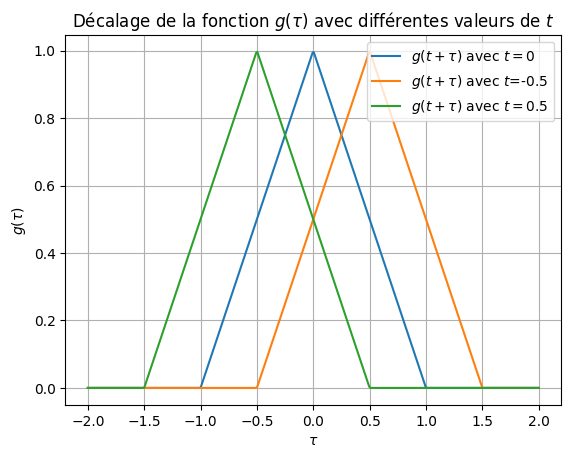

In [10]:
# Définition de la fonction g(t)
def g(t):
    return np.maximum(0, 1 - np.abs(t))

# Création de valeurs pour tau
tau = np.linspace(-2, 2, 400)

# Affichage de g(t) avec t = 0
plt.plot(tau, g(tau), label=r'$g(t+\tau)$ avec $t=0$')

# Affichage de g(t) avec t négatif (décalage vers la droite)
t_negatif = -0.5
plt.plot(tau, g(tau + t_negatif), label=r'$g(t+\tau)$ avec $t$=-0.5')

# Affichage de g(t) avec t positif (décalage vers la gauche)
t_positif = 0.5
plt.plot(tau, g(tau + t_positif), label=r'$g(t+\tau)$ avec $t=0.5$')

plt.xlabel(r'$\tau$')
plt.ylabel(r'$g(\tau)$')
plt.legend()
plt.grid(True)
plt.title(r'Décalage de la fonction $g(\tau)$ avec différentes valeurs de $t$')
plt.show()



Nous observons que lors de l'opération d'inter-corrélation, $t$ est balayé entre  $-\infty$  et  $+\infty$.

Lors de ce balayage, nous considérons une valeur donnée de $t$ et cherchons à obtenir l'aire sous la courbe du produit $f(\tau)g(t+\tau)$. L'étude des variations de cette aire fournie une idée sur la similarité des deux fonctions considérées.  Dans le cas particulier où nous avons $f(\tau) = g(\tau)$, l'inter-corrélation s'intéresse pour un $t$ donné, l'aire sous la courbe $f(\tau)f(t+\tau)$. Si les deux fonctions se superposent, i.e., $t = 0$, alors l'aire sous la courbe sera maximale, ce qui indique une similarité parfaite entre les deux fonctions. Dans le cas où $f(\tau) = g(\tau)$, nous parlons plus spécifiquement d'auto-corrélation.

$\color{orange}{\text{b)}}$  Considérer le cas de l'auto-corrélation d'une fonction carrée standard entre $t=3$ et $t=5$. Calculons l'aire sous la courbe pour $t=1$ dans l'intégrale d'auto-corrélation.

**Rappel** : une fonction rectangle est définie à l'aide de fonctions de Heaviside tel que pour un rectangle entre $t_1$ et $t_2$, nous avons:

$$
\mathrm{rect}(t)_{[t_1, t_2]} = u(t-t_2) - u(t-t_1).
$$

/tmp/ipython-input-4255732119.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_under_curve = np.trapz(product, tau)


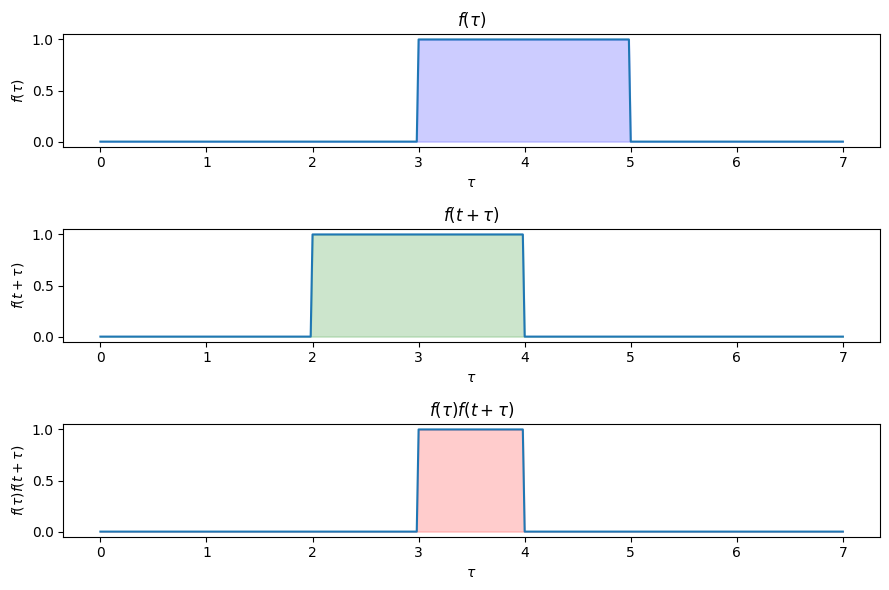

Aire sous la courbe du produit : 1.00


In [11]:

# Fonction carrée standard
def f(t):
    return np.where(np.logical_and(t >= 3, t < 5), 1, 0)

# Valeur de t fixée à 1
t = 1

# Séquence de valeurs pour tau
tau = np.linspace(0, 7, 400)

# Calcul de f(t)
ftau = f(tau)

# Calcul de f(t+tau)
ftau_t = f(t + tau)

# Calcul du produit f(t)*f(t+tau)
product = ftau * ftau_t

# Calcul de l'aire sous la courbe du produit
area_under_curve = np.trapz(product, tau)

# Affichage de f(t)
plt.figure(figsize=(9, 6))

plt.subplot(311)
plt.plot(tau, ftau)
plt.fill_between(tau, 0, ftau, alpha=0.2, color='blue')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$f(\tau)$')
plt.title(r'$f(\tau)$')

# Affichage de f(t+tau)
plt.subplot(312)
plt.plot(tau, ftau_t)
plt.fill_between(tau, 0, ftau_t, alpha=0.2, color='green')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$f(t+\tau)$')
plt.title(r'$f(t+\tau)$')

# Affichage du produit f(t)*f(t+tau)
plt.subplot(313)
plt.plot(tau, product)
plt.fill_between(tau, 0, product, alpha=0.2, color='red')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$f(\tau) f(t+\tau)$')
plt.title(r'$f(\tau) f(t+\tau)$')


plt.tight_layout()
plt.show()

# Affichage de l'aire sous la courbe du produit
print(f'Aire sous la courbe du produit : {area_under_curve:.2f}')



$\color{orange}{\text{c)}}$ Comparons l'aire sous la courbe pour différentes valeurs de $t$



/tmp/ipython-input-526286350.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_under_curve = np.trapz(product, tau)


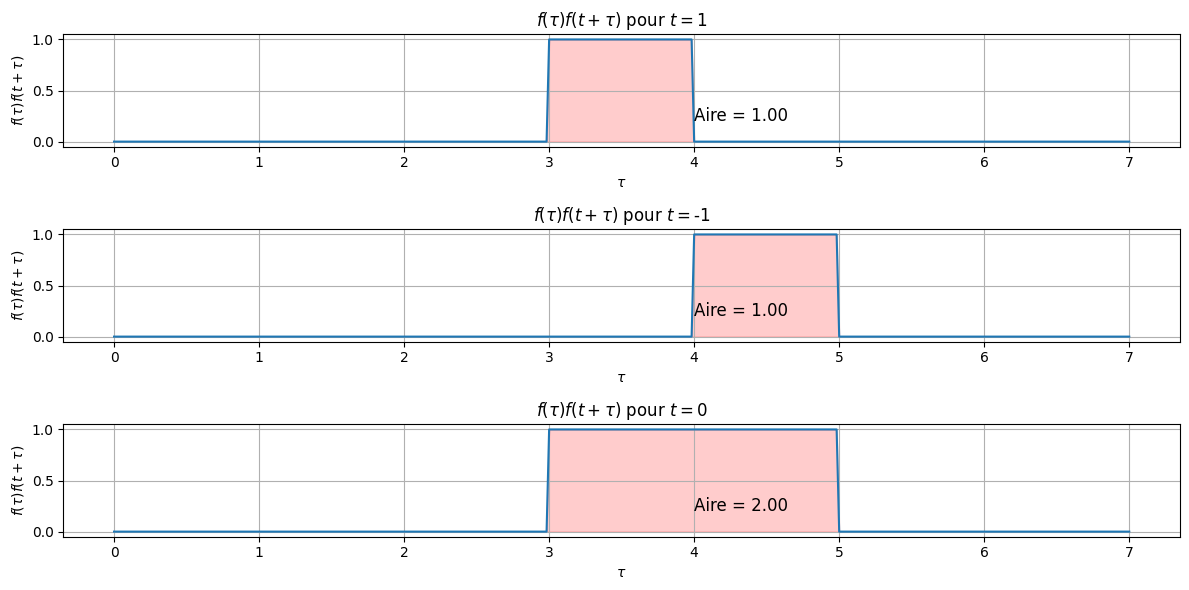

In [12]:

def f(t):
    return np.where(np.logical_and(t >= 3, t < 5), 1, 0)

# Séquence de valeurs pour t
tau = np.linspace(0, 7, 400)

# Différentes valeurs de tau
t_vec = [1, -1, 0]

# Créez une figure pour afficher les trois graphiques
plt.figure(figsize=(12, 6))

for t in t_vec:
    # Calcul de f(tau)
    ftau = f(tau)

    # Calcul de f(t+tau)
    ftau_t = f(tau + t)

    # Calcul du produit f(t)*f(t+tau)
    product = ftau * ftau_t

    # Calcul de l'aire sous la courbe du produit
    area_under_curve = np.trapz(product, tau)

    # Créez un subplot pour chaque tau
    plt.subplot(len(t_vec), 1, t_vec.index(t) + 1)

    # Affichage de f(t)*f(t+tau)
    plt.plot(tau, product, label=f'Aire = {area_under_curve:.2f} (tau = {t})')
    plt.fill_between(tau, 0, product, alpha=0.2, color='red')

    plt.xlabel(r'$\tau$')
    plt.ylabel(r'$f(\tau)f(t+\tau)$')
    plt.title(rf'$f(\tau)f(t+\tau)$ pour $t = ${t}')
    plt.grid(True)

    # Ajouter le texte pour afficher l'aire sous la courbe
    plt.text(4, 0.2, f'Aire = {area_under_curve:.2f}', fontsize=12, color='black')

plt.tight_layout()
plt.show()

Dans les applications radars, nous aurons un signal de retour différent de $f(t)$, que nous appelons $g(t)$. Afin de déterminer si $g(t)$ est un signal d'intérêt, nous devons le comparer à un signal de référence, typiquement celui-ci sera l'auto-corrélation de la fonction $f(t)$. Ceci sera discuté à l'Exercice 3.

## $\color{#03fc9d}{\textbf{Exercice 1, évalué en classe (8pt/20):}}$

$\color{orange}{\text{a) [code]}}$ Évaluer l'intégrale d'inter-corrélation entre les deux signaux suivants (utiliser la fonction d'inter-corrélation de votre choix, nous proposons `numpy.correlate`): $\color{red}{\textbf{(1pt/20)}}$



1.   Premier signal : signal rectangulaire ayant un maximum de 1, compris entre 3 et 5
2.   Second signal : signal rectangulaire ayant un maximum de 1, compris entre 1 et 3

>⚠ **Attention:**
>
> Utiliser un intervalle d'affichage symétrique pour l'inter-corrélation.
>
> Penser à afficher votre figure de manière descriptive (ici avoir des figures `signal1`, `signal2` et `intercorrélation` disposées les unes sous les autres semble être pertinent par exemple).
>



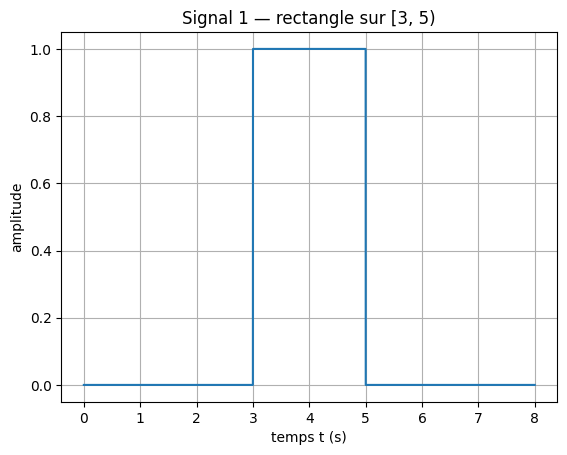

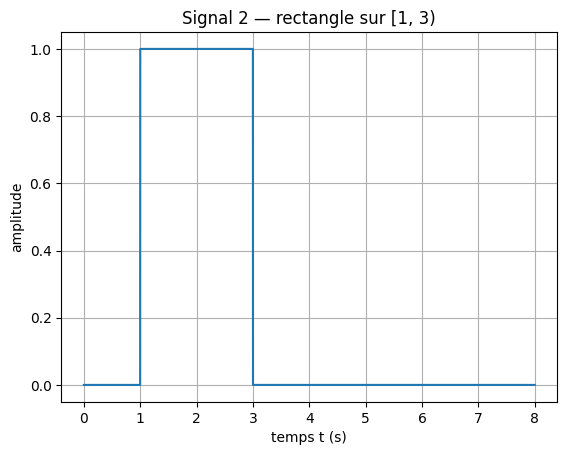

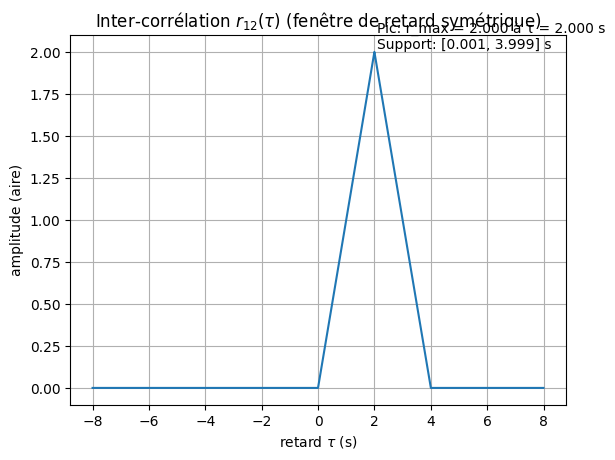

=== Résumé numérique ===
Pic d'inter-corrélation : r_max = 2.000000 à τ = 2.000000 s
Support où r(τ) > 0 : [0.001000, 3.999000] s


In [13]:
# Écrire votre code ici pour a)

import numpy as np
import matplotlib.pyplot as plt

# Discrétisation temporelle
dt = 1e-3                 # pas d'échantillonnage (s)
t_min, t_max = 0.0, 8.0   # fenêtre d'observation (s)
t = np.arange(t_min, t_max, dt)

# Fonction rectangle : 1 sur [a, b) sinon 0
def rect_interval(x, a, b):
    return np.where((x >= a) & (x < b), 1.0, 0.0)

# Signaux
s1 = rect_interval(t, 3.0, 5.0)   # signal 1 : rectangle sur [3, 5)
s2 = rect_interval(t, 1.0, 3.0)   # signal 2 : rectangle sur [1, 3)

# Inter-corrélation discrète (mode 'full')
# numpy.correlate(a, b, 'full')[k] = sum_i a[i] * b[i+k]
# Pour approcher l'intégrale continue, on multiplie par dt.
r = np.correlate(s1, s2, mode='full') * dt

# Axe des retards (tau) — symétrique
lags = np.arange(-len(s1)+1, len(s2)) * dt  # en secondes

# Infos utiles
tau_peak = lags[np.argmax(r)]
r_peak = np.max(r)
support_indices = np.where(r > 0)[0]
tau_support = (lags[support_indices[0]], lags[support_indices[-1]]) if support_indices.size > 0 else (None, None)

# --- Figure 1 : signal 1 ---
plt.figure()
plt.plot(t, s1)
plt.title("Signal 1 — rectangle sur [3, 5)")
plt.xlabel("temps t (s)")
plt.ylabel("amplitude")
plt.grid(True)

# --- Figure 2 : signal 2 ---
plt.figure()
plt.plot(t, s2)
plt.title("Signal 2 — rectangle sur [1, 3)")
plt.xlabel("temps t (s)")
plt.ylabel("amplitude")
plt.grid(True)

# --- Figure 3 : inter-corrélation ---
plt.figure()
plt.plot(lags, r)
plt.title("Inter-corrélation $r_{12}(\\tau)$ (fenêtre de retard symétrique)")
plt.xlabel("retard $\\tau$ (s)")
plt.ylabel("amplitude (aire)")
plt.grid(True)

# Annotation des infos clés (pic et support)
txt = f"Pic: r_max = {r_peak:.3f} à τ = {tau_peak:.3f} s\nSupport: [{tau_support[0]:.3f}, {tau_support[1]:.3f}] s"
plt.annotate(txt, xy=(tau_peak, r_peak), xytext=(tau_peak, r_peak), textcoords="offset points")

plt.show()

# Résumé numérique dans la console
print("=== Résumé numérique ===")
print(f"Pic d'inter-corrélation : r_max = {r_peak:.6f} à τ = {tau_peak:.6f} s")
print(f"Support où r(τ) > 0 : [{tau_support[0]:.6f}, {tau_support[1]:.6f}] s")


$\color{orange}{\text{b) [Démarche manuscrite]}}$ Considérer d'abord le signal rectangulaire $x(t)$:

$$
x(t) = \sum_{n \in \mathbb{Z}} \tilde{\Pi}(t-nT)
$$

où

\begin{align*}
\tilde{\Pi}(t) &= \begin{cases}
1, &\text{ si } 0 \leq t < T/2\\
-1, &\text{ si } T/2 \leq t < T\\
0, &\text{ sinon,}\end{cases}
\end{align*}

Déterminer analytiquement l'auto-corrélation du signal $x(t)$. $\color{red}{\textbf{(2pt/20)}}$



---

---


*Insérer une photo de vos démarches pour (b) (papier, $\LaTeX$ ou tablette)*.



---

---


$\color{orange}{\text{c) [code]}}$ Effectuer l'opération d'auto-corrélation numérique sur le signal $x(t)$ défini à la question précédente.  **(utiliser la fonction `correlate` de `numpy` avec l'option `mode="full"`)**

*  $T$ = 0.1s;
*   Durée du signal = 1 s;
*   Fréquence d'échantillonnage $f_\text{s}$ = 4000 Hz.

Comparer le résultat numérique au résultat théorique obtenu à la question b). Comment expliquez vous les différences? $\color{red}{\textbf{(1pt/20)}}$

>⚠ **Attention:**
>
> Afficher votre fonction d'inter-corrélation entre -1 et 1 pour le reste du TP. Pour ce faire en considérant un vecteur de temps $t$ standard, utiliser cette expression du temps lors de l'affichage d'un signal de corrélation :
>
>`t_autocorr = np.arange(-t[-1], t[-1] + 1/fs, 1/fs)`
>
>



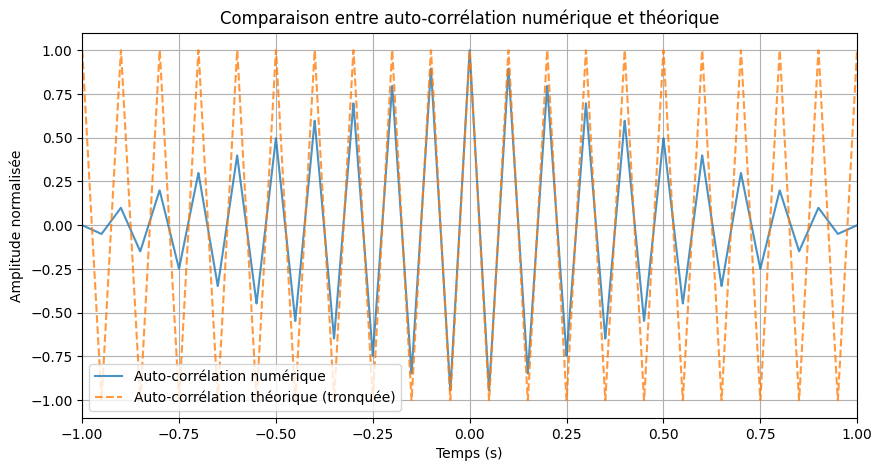

In [14]:
# Écrire votre code ici pour c)

# Paramètres
T = 0.1
duration = 1.0
fs = 4000
Ts = 1 / fs


# Vecteur temps
t = np.arange(0, duration, Ts)

# Définition du signal x(t) : alternance +1 / -1 dans chaque période T
x = np.where((t % T) < (T/2), 1.0, -1.0)

# Auto-corrélation numérique (mode 'full')
Rxx_num = np.correlate(x, x, mode="full")
Rxx_num = Rxx_num / np.max(Rxx_num)  # normalisation entre -1 et 1

# Axe des temps pour la corrélation (symétrique)
t_autocorr = np.arange(-t[-1], t[-1] + Ts, Ts)

# ---- Théorie ----
# Série de Fourier tronquée pour approximer Rxx_th(t)
Kmax = 20  # nombre d'harmoniques impaires prises en compte
Rxx_th = np.zeros_like(t_autocorr, dtype=complex)
for k in range(-Kmax, Kmax + 1):
    Rxx_th += (4 / (np.pi**2 * (2*k + 1)**2)) * np.exp(1j * 2*np.pi*(2*k + 1)*t_autocorr / T)
Rxx_th = np.real(Rxx_th)
Rxx_th = Rxx_th / np.max(Rxx_th)  # normalisation

# ---- Affichage ----
plt.figure(figsize=(10, 5))
plt.plot(t_autocorr, Rxx_num, label="Auto-corrélation numérique", alpha=0.8)
plt.plot(t_autocorr, Rxx_th, "--", label="Auto-corrélation théorique (tronquée)", alpha=0.8)
plt.xlim(-1, 1)  # comme demandé : affichage entre -1 et 1
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude normalisée")
plt.title("Comparaison entre auto-corrélation numérique et théorique")
plt.legend()
plt.grid(True)
plt.show()


$\color{orange}{\text{d) [Code]}}$ Introduire un délai dans le signal $x(t)$ et évaluer l'inter-corrélation entre le signal initial et sa version avec délai. Afficher le signal d'intercorrélation $\color{red}{\textbf{(1pt/20)}}$

*   Délai (en secondes) = Numéro d'équipe/1000.





Délai appliqué = 0.102 s


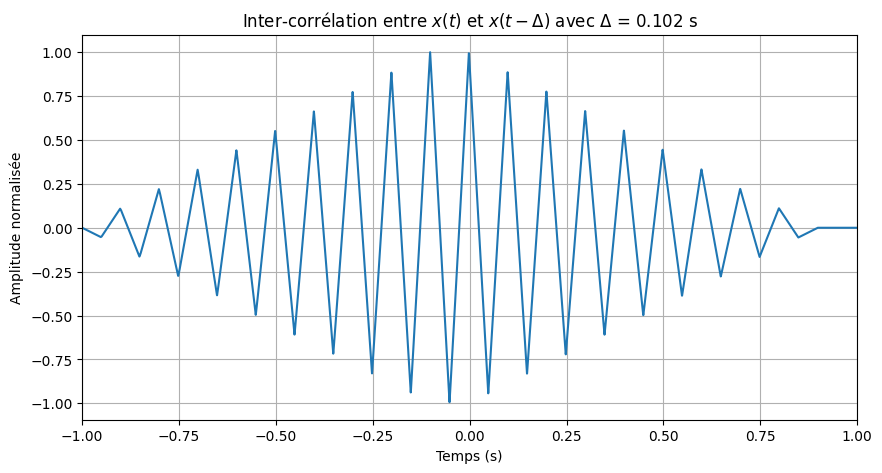

In [15]:
# Écrire votre code ici pour d)

# Paramètres
T = 0.1
duration = 1.0
fs = 4000
Ts = 1 / fs


num_equipe = 102
delay = num_equipe / 1000.0  # délai en secondes
print(f"Délai appliqué = {delay:.3f} s")

# === Définition du signal x(t) ===
t = np.arange(0, duration, Ts)
x = np.where((t % T) < (T/2), 1.0, -1.0)

# === Création du signal retardé ===
# Décalage en échantillons
delay_samples = int(round(delay * fs))

# Décalage du signal : on insère des zéros au début
x_delayed = np.concatenate((np.zeros(delay_samples), x[:-delay_samples]))

# === Calcul de l’inter-corrélation ===
Rxy = np.correlate(x, x_delayed, mode='full')
Rxy = Rxy / np.max(Rxy)  # normalisation

# Axe temporel pour la corrélation
t_autocorr = np.arange(-t[-1], t[-1] + Ts, Ts)

# === Affichage ===
plt.figure(figsize=(10, 5))
plt.plot(t_autocorr, Rxy)
plt.title(fr"Inter-corrélation entre $x(t)$ et $x(t-\Delta)$ avec $\Delta$ = {delay:.3f} s")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude normalisée")
plt.xlim(-1, 1)  # affichage demandé entre -1 et 1 s
plt.grid(True)
plt.show()


$\color{orange}{\text{e) [code]}}$ Calculer le délai entre les maxima de l'inter-corrélation pour la question c) et d). $\color{red}{\textbf{(1pt/20)}}$


Délai appliqué = 0.102 s
=== Résumé ===
Pic corrélation (auto) : τ_auto = 0.000000 s
Pic corrélation (retardée) : τ_inter = -0.102000 s
➡ Délai mesuré entre les maxima : Δτ = -0.102000 s (attendu ≈ 0.102000 s)


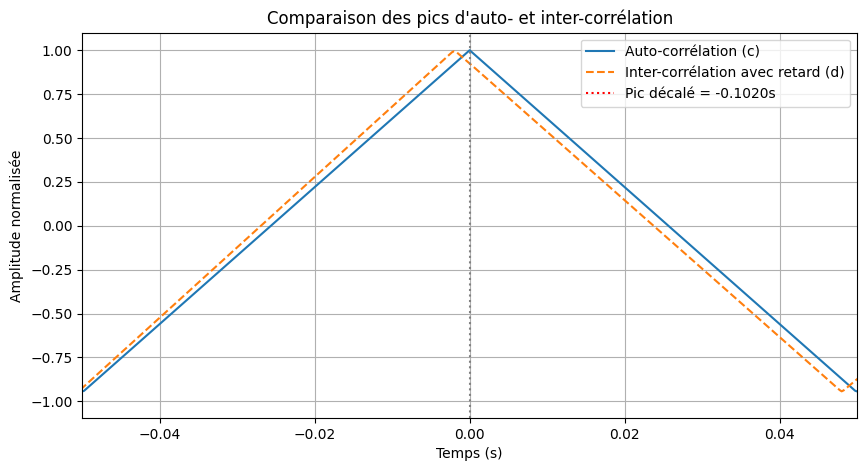

In [16]:
# Écrire votre code ici pour e)

# --- Paramètres ---
T = 0.1
duration = 1.0
fs = 4000
Ts = 1/fs
num_equipe = 102
delay = num_equipe / 1000.0  # s
print(f"Délai appliqué = {delay:.3f} s")

# --- Signal de base ---
t = np.arange(0, duration, Ts)
x = np.where((t % T) < (T/2), 1.0, -1.0)

# === Corrélation (c) : auto-corrélation ===
Rxx = np.correlate(x, x, mode="full")
Rxx = Rxx / np.max(np.abs(Rxx))
lags = np.arange(-len(x)+1, len(x)) / fs

# === Corrélation (d) : inter-corrélation avec retard ===
delay_samples = int(round(delay * fs))
x_delayed = np.concatenate((np.zeros(delay_samples), x[:-delay_samples]))
Rxy = np.correlate(x, x_delayed, mode="full")
Rxy = Rxy / np.max(np.abs(Rxy))

# === Calcul des maxima ===
lag_Rxx = lags[np.argmax(Rxx)]
lag_Rxy = lags[np.argmax(Rxy)]

# Délai entre les deux maxima
delta_tau = lag_Rxy - lag_Rxx

# --- Résultats ---
print("=== Résumé ===")
print(f"Pic corrélation (auto) : τ_auto = {lag_Rxx:.6f} s")
print(f"Pic corrélation (retardée) : τ_inter = {lag_Rxy:.6f} s")
print(f"➡ Délai mesuré entre les maxima : Δτ = {delta_tau:.6f} s (attendu ≈ {delay:.6f} s)")

# --- Affichage comparatif ---
plt.figure(figsize=(10,5))
plt.plot(lags, Rxx, label="Auto-corrélation (c)")
plt.plot(lags, Rxy, label="Inter-corrélation avec retard (d)", linestyle="--")
plt.axvline(lag_Rxy, color="red", linestyle=":", label=f"Pic décalé = {lag_Rxy:.4f}s")
plt.axvline(0, color="gray", linestyle=":")
plt.xlim(-0.05, 0.05)  # zoom autour du pic pour bien visualiser le décalage
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude normalisée")
plt.title("Comparaison des pics d'auto- et inter-corrélation")
plt.legend()
plt.grid(True)
plt.show()


$\color{orange}{\text{f) [Texte]}}$ Expliquer en vos termes pourquoi choisir un délai s'approchant de la période du signal périodique initial fausse le calcul de délai avec l'inter-corrélation. $\color{red}{\textbf{(2pt/20)}}$

**Écrire votre réponse ici pour f).**



## $\color{#03fc9d}{\textbf{Exercice 2, évalué en classe (2pt/20):}}$
 À la lumière de vos expériences, choisir un signal périodique pour le calcul de délai dans le cadre d'un système radar (passif ou non) n'est pas une bonne option. Au TP-3, nous avons étudié avec profondeur la composition fréquentielle et le motif d'un signal *chirp* : c'est un signal fréquemment utilisé dans le contexte de systèmes radars passifs du fait de sa non-périodicité ainsi que de sa large couverture du domaine fréquentiel.

 Considérons l'étude du signal *chirp* suivant :

In [17]:
def chirp_signal(f0, f1, t, T):
    # Générer un signal chirp continu
    return np.sin(2 * np.pi * (f0 * t + ((f1 - f0) / T) * t**2))

# Paramètres du signal chirp
f0 = 10  # Fréquence de départ du chirp (en Hz)
f1 = 100  # Fréquence finale du chirp (en Hz)
T = 1.0  # Durée du signal chirp (en secondes)

# Fréquence d'échantillonnage
fs = 1000  # Hz
t = np.arange(0, T, 1/fs)

# Générer un signal chirp continu
signal = chirp_signal(f0, f1, t, T)

$\color{orange}{\text{a) [code]}}$ Générer un signal *chirp* bruité en retard de 0.2s à partir du signal chirp plus haut. Évaluer l'inter-corrélation entre le signal *chirp* fourni et sa version retardée et bruitée. **(utiliser `np.random.randn()` pour générer du bruit)**  $\color{red}{\textbf{(1.5pt/20)}}$

Délai appliqué = 0.200 s -> 200 échantillons


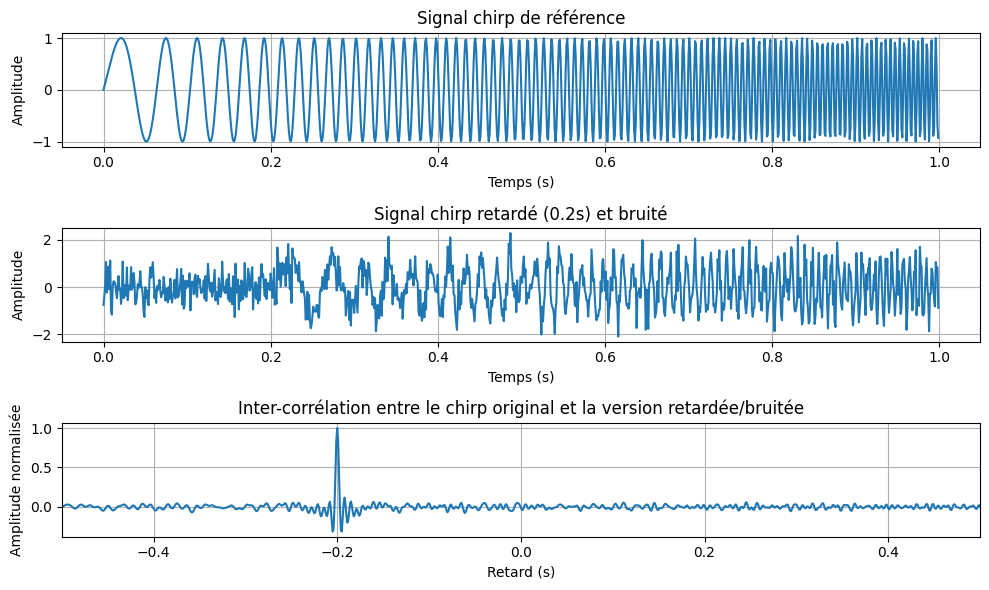

Pic de corrélation à τ = -0.200 s (attendu ≈ 0.200 s)


In [18]:
# Écrire votre code ici pour a)
Ts = 1 / fs

# --- Création du signal retardé et bruité ---
delay = 0.2  # s
delay_samples = int(delay * fs)
print(f"Délai appliqué = {delay:.3f} s -> {delay_samples} échantillons")

# Décalage temporel : insertion de zéros au début
signal_delayed = np.concatenate((np.zeros(delay_samples), signal[:len(signal) - delay_samples]))

# Ajout de bruit blanc gaussien (variance ajustable)
noise_level = 0.5
signal_noisy = signal_delayed + noise_level * np.random.randn(len(signal_delayed))

# --- Inter-corrélation ---
Rxy = np.correlate(signal, signal_noisy, mode="full")
Rxy = Rxy / np.max(np.abs(Rxy))  # normalisation
lags = np.arange(-len(signal) + 1, len(signal)) / fs

# --- Affichage ---
plt.figure(figsize=(10, 6))

# 1. Signal de référence
plt.subplot(3, 1, 1)
plt.plot(t, signal)
plt.title("Signal chirp de référence")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True)

# 2. Signal retardé et bruité
plt.subplot(3, 1, 2)
plt.plot(t, signal_noisy[:len(t)])
plt.title(f"Signal chirp retardé ({delay}s) et bruité")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True)

# 3. Inter-corrélation
plt.subplot(3, 1, 3)
plt.plot(lags, Rxy)
plt.title("Inter-corrélation entre le chirp original et la version retardée/bruitée")
plt.xlabel("Retard (s)")
plt.ylabel("Amplitude normalisée")
plt.xlim(-0.5, 0.5)
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Estimation du délai à partir du pic de corrélation ---
tau_estime = lags[np.argmax(Rxy)]
print(f"Pic de corrélation à τ = {tau_estime:.3f} s (attendu ≈ {delay:.3f} s)")

$\color{orange}{\text{b) [code]}}$ Afficher le signal *chirp*, son équivalent bruité et l'inter-corrélation des deux (rappel : faire un affichage sur $[-1,1]$ pour l'intercorrélation). $\color{red}{\textbf{(0.5pt/20)}}$

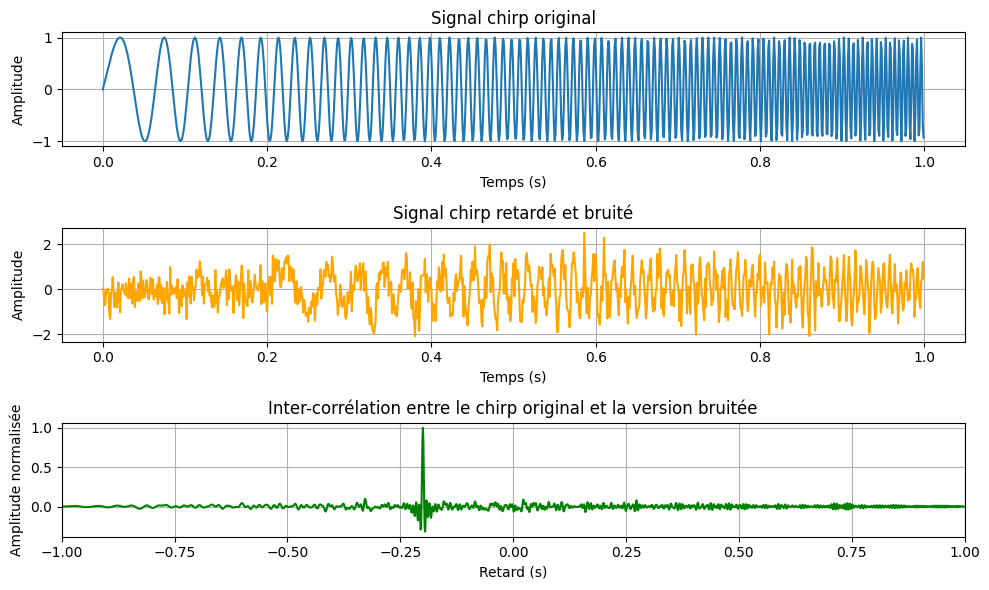

In [19]:
# Écrire votre code ici pour b)

# --- Création de la version retardée et bruitée ---
delay = 0.2  # secondes
delay_samples = int(delay * fs)

signal_delayed = np.concatenate((np.zeros(delay_samples), signal[:len(signal) - delay_samples]))
noise_level = 0.5
signal_noisy = signal_delayed + noise_level * np.random.randn(len(signal_delayed))

# --- Inter-corrélation ---
Rxy = np.correlate(signal, signal_noisy, mode='full')
Rxy = Rxy / np.max(np.abs(Rxy))
t_autocorr = np.arange(-t[-1], t[-1] + Ts, Ts)

# --- Affichage ---
plt.figure(figsize=(10, 6))

# Signal original
plt.subplot(3, 1, 1)
plt.plot(t, signal, label='Signal chirp original')
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.title("Signal chirp original")
plt.grid(True)

# Signal bruité
plt.subplot(3, 1, 2)
plt.plot(t, signal_noisy[:len(t)], label='Signal bruité', color='orange')
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.title("Signal chirp retardé et bruité")
plt.grid(True)

# Inter-corrélation
plt.subplot(3, 1, 3)
plt.plot(t_autocorr, Rxy, label='Inter-corrélation', color='green')
plt.xlim(-1, 1)  # affichage sur [-1, 1]
plt.xlabel("Retard (s)")
plt.ylabel("Amplitude normalisée")
plt.title("Inter-corrélation entre le chirp original et la version bruitée")
plt.grid(True)

plt.tight_layout()
plt.show()



## $\color{#03fc9d}{\textbf{Exercice 3, devoir (10pt/20):}}$

Nous considérons maintenant un signal *chirp exponentiel* dont l'expression est donnée ci-dessous :

$$
x(t) = \text{cos}\left(\omega_0\left(\frac{T(k^{t/T}-1)}{\ln(k)}\right)\right),
$$
où :
*   $\omega_0$ = $2\pi$ Hz;
*   $k$ = e
*   $T$ = 1 s;
*   $f_s$ = 1000 Hz.




In [29]:
def chirp_signal(w0, k, t, T):
    # Générer un signal chirp continu
    return np.cos(w0 * T * (k**(t/T)-1)/np.log2(k))

# Paramètres du signal chirp
w0 = 2*np.pi  # Fréquence de départ du chirp (en Hz)
k = np.e  # Taux de variation de la fréquence
T = 1  # Temps où f_T = k*f_0 (en secondes)

# Fréquence d'échantillonnage
fs = 1000  # Hz
tf = 2 # Durée du signal
t = np.arange(0, tf, 1/fs)

# Générer un signal chirp continu
signal = chirp_signal(f0, f1, t, T)

$\color{orange}{\text{a) [Photos dans case texte]}}$ Donner l'expression analytique d'auto-corrélation d'un signal *chirp* avec lui-même. Prendre les paramètres suivants : $\color{red}{\textbf{(3pt/20)}}$

*   $\omega_0$ = $2\pi$ Hz;
*   $k$ = e;
*   $T$ = 1 s.

Ainsi, donner l'expression d'autocorrélation du signal:

$$
\cos\left(2\pi \mathrm{e}^t\right).
$$

Utiliser les trois premiers termes du développement en série de Taylor pour approximer $\mathrm{e}^t$ comme au TP-3.


---

---


*Insérer une photo de vos démarches pour (e) (papier, $\LaTeX$ ou tablette)*.



---

---

# <font color='green'> Analyse d'un signal radar issu d'un environnement et d'une cible inconnus </font>


À partir de maintenant, nous nous plaçons dans le contexte de simulation d'un radar standard. Le signal suit donc le chemin suivant: aller jusqu'à une cible, réflexion depuis la cible et retour vers le radar. L'aller et le retour se fait dans un milieu de propagation. Ce milieu sera simulé par un environnment boîte noire. Cet aller-retour est effectué pour chaque cible présente.

Télécharger sur `Moodle` le fichier `blackbox_tp4.so` et rouler la commande suivante.

In [21]:
from google.colab import files

S'assurer d'avoir téléchargé le fichier `blackbox_tp4.so` avant l'étape suivante. Le sélectionner en appuyant sur `Choose Files`.

In [22]:
uploaded = files.upload() # Décommenter la première fois que vous roulez le code pour importer votre fichier blackbox_tp4 (ne pas oublier de recommenter un fois cela fait!)

Saving blackbox_tp4.so to blackbox_tp4 (1).so


**Vérifier** que le fichier a bien été téléchargé dans l'environnement actuel. Si jamais vous voulez retirer un fichier, utiliser la commande suivante:

In [23]:
!ls -lh
# !rm blackbox_tp4.so  #Commande pour retirer un fichier, si nécessaire. Laisser en commentaire.

total 468K
-rw-r--r-- 1 root root 231K Nov 11 15:51 'blackbox_tp4 (1).so'
-rw-r--r-- 1 root root 231K Nov 11 15:45  blackbox_tp4.so
drwxr-xr-x 1 root root 4.0K Nov  7 14:30  sample_data


Une fois le fichier `blackbox_tp4` importé, rouler la commande suivante:

In [24]:
import blackbox_tp4

Le fichier `blackbox_tp4` contient l'exécutable de la fonction boîte noire `blackbox1`, que nous considérons être un milieu de propagation contenant de l'air. La fonction accepte les arguments suivants:


*   Argument 1: signal d'entrée.

Elle retourne le signal modifié dû à son passage dans le milieu de propagation.
Voici un exemple d'utilisation:

`blackbox_tp4.blackbox1(signal)`

$\color{orange}{\text{b) [code]}}$ Avec l'aide de la boîte noire fournie : Injecter le signal *chirp exponentiel* (signal décrit dans la case de code au début de l'exercice 3 où $\omega_0$ = $2\pi$ Hz, $k$ = e, $T$ = 1 s) dans la boîte noire et évaluer l'inter-corrélation entre le signal *chirp exponentiel* et sa sortie. $\color{red}{\textbf{(1pt/20)}}$

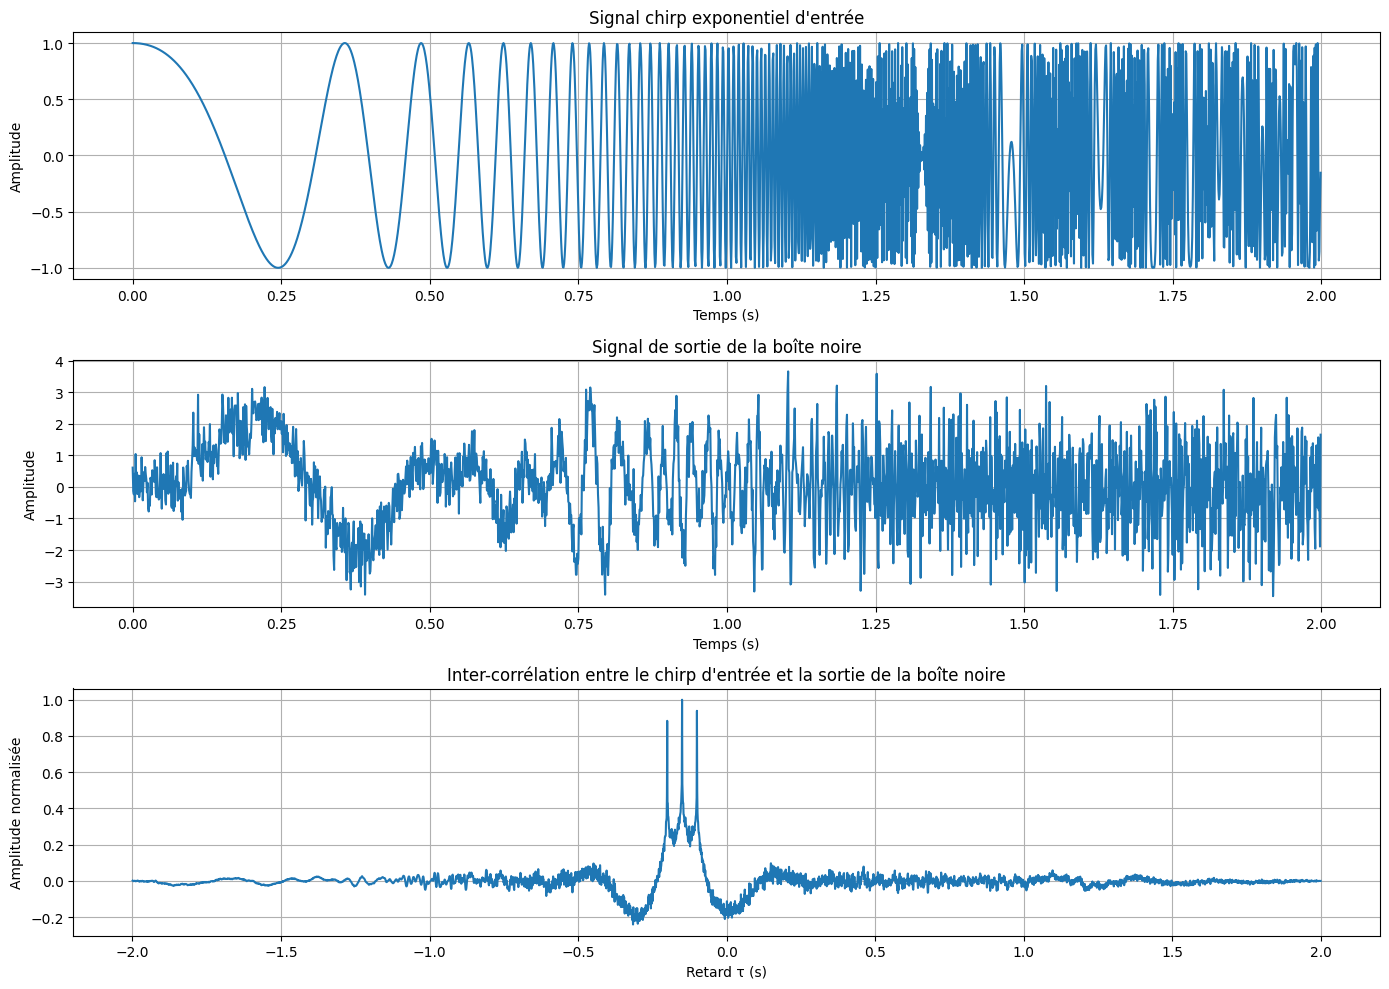

Longueur du signal d'entrée: 2000 échantillons
Longueur du signal de sortie: 2000 échantillons
Position du maximum d'inter-corrélation: -0.150000 s


In [33]:
# Écrire votre code ici pour b)
# Imports nécessaires
import numpy as np
import matplotlib.pyplot as plt
import blackbox_tp4

def chirp_signal(w0, k, t, T):
    # Générer un signal chirp continu
    return np.cos(w0 * T * (k**(t/T)-1)/np.log2(k))

# Paramètres du signal chirp
w0 = 2*np.pi  # Fréquence de départ du chirp (en Hz)
k = np.e  # Taux de variation de la fréquence
T = 1  # Temps où f_T = k*f_0 (en secondes)

# Fréquence d'échantillonnage
fs = 1000  # Hz
tf = 2 # Durée du signal
t = np.arange(0, tf, 1/fs)

# Générer un signal chirp continu
chirp_input = chirp_signal(f0, f1, t, T)

chirp_output =  blackbox_tp4.blackbox1(chirp_input)

Rxy = np.correlate(signal, chirp_output, mode='full')

Rxy_normalized = Rxy / np.max(np.abs(Rxy))

dt = 1/fs

lags = np.arange(-len(chirp_input)+1, len(chirp_output)) * dt

plt.figure(figsize=(14, 10))

# Signal d'entrée (chirp)
plt.subplot(3, 1, 1)
plt.plot(t, chirp_input)
plt.title("Signal chirp exponentiel d'entrée")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True)

# Signal de sortie de la boîte noire
plt.subplot(3, 1, 2)
plt.plot(t, chirp_output)
plt.title("Signal de sortie de la boîte noire")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True)

# Inter-corrélation normalisée
plt.subplot(3, 1, 3)
plt.plot(lags, Rxy_normalized)
plt.title("Inter-corrélation entre le chirp d'entrée et la sortie de la boîte noire")
plt.xlabel("Retard τ (s)")
plt.ylabel("Amplitude normalisée")
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Longueur du signal d'entrée: {len(chirp_input)} échantillons")
print(f"Longueur du signal de sortie: {len(chirp_output)} échantillons")
print(f"Position du maximum d'inter-corrélation: {lags[np.argmax(Rxy_normalized)]:.6f} s")



$\color{orange}{\text{c) [code et interprétation]}}$  Afficher sur le même graphique le signal *chirp exponentiel* d'entrée, le signal en sortie de la boîte noire, le signal d'auto-corrélation du *chirp exponentiel* et le signal d'inter-corrélation entre *chirp exponentiel* et la sortie. Expliquer pourquoi l'inter-corrélation se déplace à gauche ou à droite (selon ce qui est observeé) en comparaison à l'auto-corrélation. $\color{red}{\textbf{(3pt/20)}}$

Maximum d'auto-corrélation à τ = 0.000000 s
Maximum d'inter-corrélation à τ = -0.150000 s


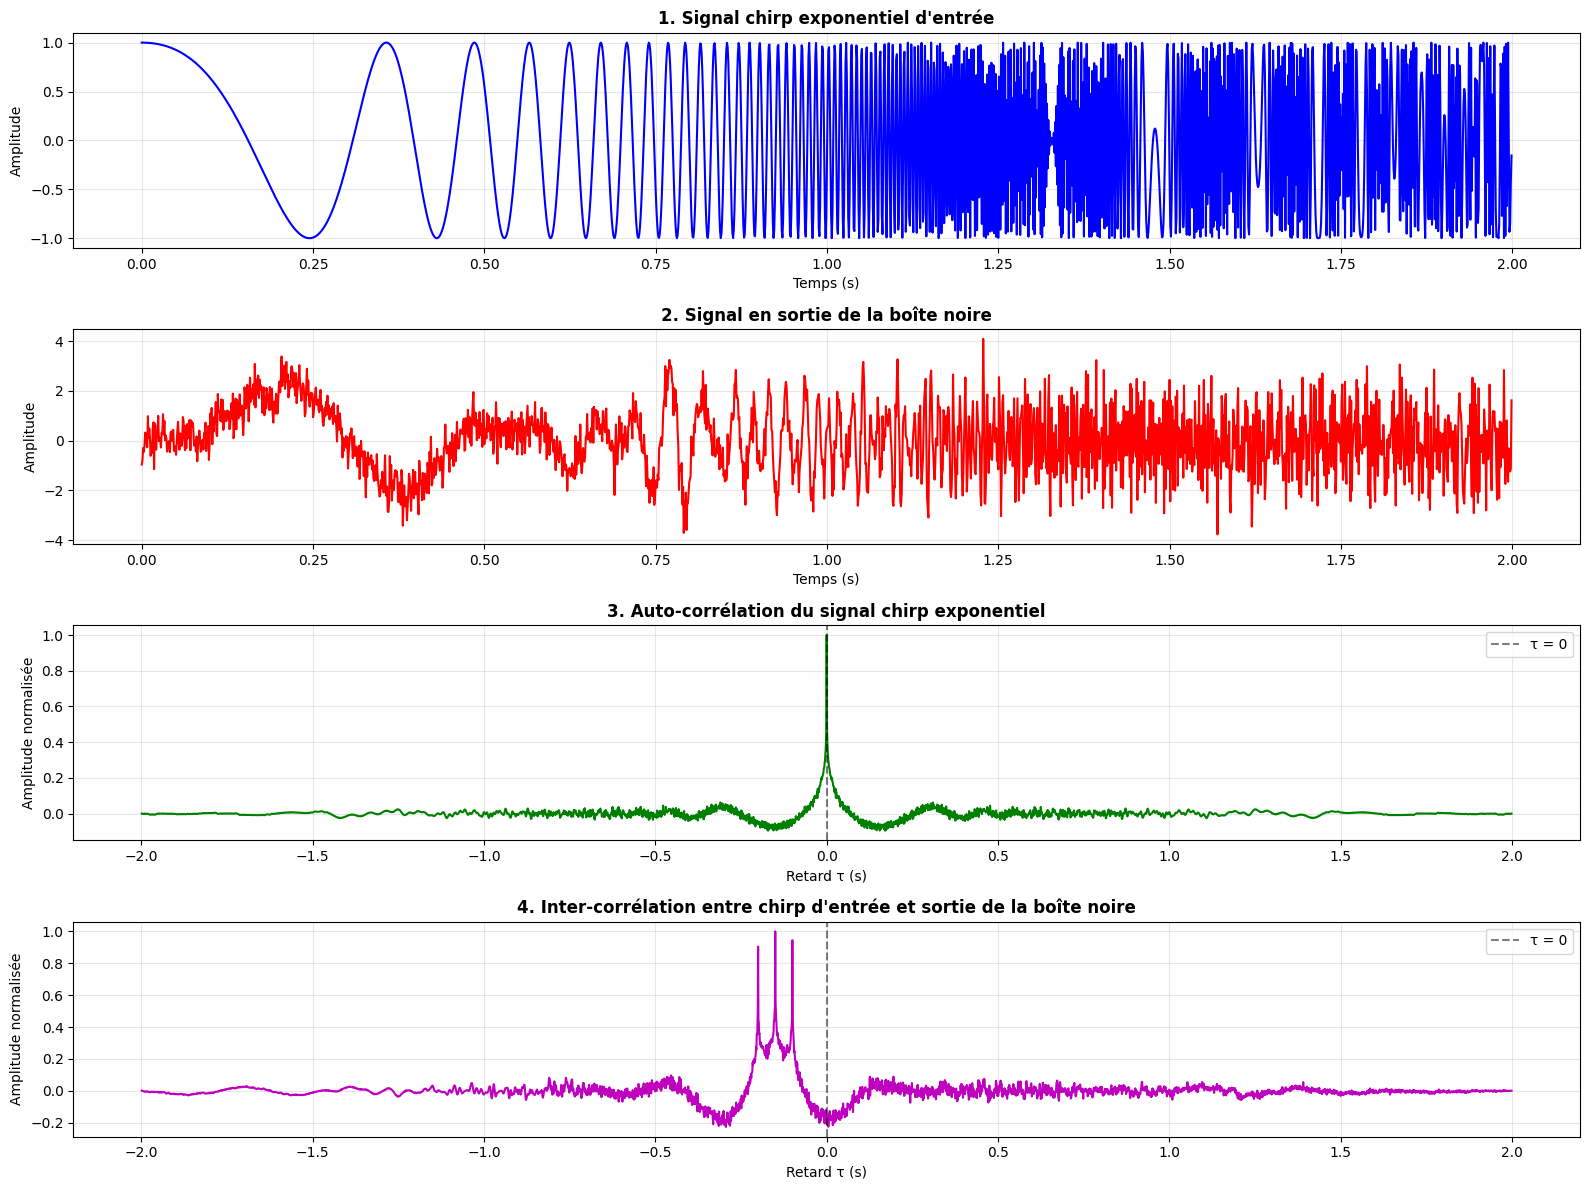

Maximum d'auto-corrélation à τ = 0.000000 s
Maximum d'inter-corrélation à τ = -0.150000 s

Décalage (délai) = -0.150000 s
Décalage en échantillons : -150 échantillons

Nombre de pics détectés (cibles potentielles) : 3
Positions des pics (délais) :
  Cible 1: τ = -0.200000 s, amplitude = 0.905
  Cible 2: τ = -0.150000 s, amplitude = 1.000
  Cible 3: τ = -0.100000 s, amplitude = 0.945


In [36]:
# Écrire votre code ici pour c)
def chirp_signal(w0, k, t, T):
    # Générer un signal chirp continu
    return np.cos(w0 * T * (k**(t/T)-1)/np.log2(k))

# Paramètres du signal chirp
w0 = 2*np.pi  # Fréquence de départ du chirp (en Hz)
k = np.e  # Taux de variation de la fréquence
T = 1  # Temps où f_T = k*f_0 (en secondes)

# Fréquence d'échantillonnage
fs = 1000  # Hz
tf = 2 # Durée du signal
t = np.arange(0, tf, 1/fs)

# Générer un signal chirp continu
chirp_input = chirp_signal(f0, f1, t, T)

chirp_output = blackbox_tp4.blackbox1(chirp_input)

# AUTO-CORRÉLATION du signal chirp
Rxx = np.correlate(chirp_input, chirp_input, mode='full')
Rxx_normalized = Rxx / np.max(np.abs(Rxx))

#INTER-CORRÉLATION entre le signal d'entrée et la sortie
Rxy = np.correlate(chirp_input, chirp_output, mode='full')
Rxy_normalized = Rxy / np.max(np.abs(Rxy))

dt = 1/fs
lags_xx = np.arange(-len(chirp_input)+1, len(chirp_input)) * dt  # Pour auto-corrélation
lags_xy = np.arange(-len(chirp_input)+1, len(chirp_output)) * dt  # Pour inter-corrélation

plt.figure(figsize=(16, 12))

# Signal chirp exponentiel d'entrée
plt.subplot(4, 1, 1)
plt.plot(t, chirp_input, 'b-', linewidth=1.5)
plt.title("1. Signal chirp exponentiel d'entrée", fontsize=12, fontweight='bold')
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)

# Signal en sortie de la boîte noire
plt.subplot(4, 1, 2)
plt.plot(t, chirp_output, 'r-', linewidth=1.5)
plt.title("2. Signal en sortie de la boîte noire", fontsize=12, fontweight='bold')
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)

# Auto-corrélation du signal chirp
plt.subplot(4, 1, 3)
plt.plot(lags_xx, Rxx_normalized, 'g-', linewidth=1.5)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5, label='τ = 0')
plt.title("3. Auto-corrélation du signal chirp exponentiel", fontsize=12, fontweight='bold')
plt.xlabel("Retard τ (s)")
plt.ylabel("Amplitude normalisée")
plt.grid(True, alpha=0.3)
plt.legend()

max_idx_xx = np.argmax(Rxx_normalized)
max_lag_xx = lags_xx[max_idx_xx]
print(f"Maximum d'auto-corrélation à τ = {max_lag_xx:.6f} s")

# Inter-corrélation entre chirp et sortie
plt.subplot(4, 1, 4)
plt.plot(lags_xy, Rxy_normalized, 'm-', linewidth=1.5)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5, label='τ = 0')
plt.title("4. Inter-corrélation entre chirp d'entrée et sortie de la boîte noire", fontsize=12, fontweight='bold')
plt.xlabel("Retard τ (s)")
plt.ylabel("Amplitude normalisée")
plt.grid(True, alpha=0.3)
plt.legend()

max_idx_xy = np.argmax(Rxy_normalized)
max_lag_xy = lags_xy[max_idx_xy]
print(f"Maximum d'inter-corrélation à τ = {max_lag_xy:.6f} s")

plt.tight_layout()
plt.show()

print(f"Maximum d'auto-corrélation à τ = {max_lag_xx:.6f} s")
print(f"Maximum d'inter-corrélation à τ = {max_lag_xy:.6f} s")
print(f"\nDécalage (délai) = {max_lag_xy - max_lag_xx:.6f} s")
print(f"Décalage en échantillons : {int((max_lag_xy - max_lag_xx) * fs)} échantillons")

# Trouver tous les pics significatifs dans l'inter-corrélation
from scipy.signal import find_peaks
peaks, properties = find_peaks(Rxy_normalized, height=0.3, distance=50)
print(f"\nNombre de pics détectés (cibles potentielles) : {len(peaks)}")
print("Positions des pics (délais) :")
for i, peak_idx in enumerate(peaks):
    peak_lag = lags_xy[peak_idx]
    print(f"  Cible {i+1}: τ = {peak_lag:.6f} s, amplitude = {Rxy_normalized[peak_idx]:.3f}")


**Interpretation**

1. Auto-correlation (Rxx) : Compare le signal avec lui même, le max est à τ = 0, donc le signal est aligné avec lui même

2. Inter-corrélation (Rxy) : Compare le signal d'entree avec le signal de sortie, le signal est décalé de

*   τ = -0.200000 s
*   τ = -0.150000 s
*   τ = -0.100000 s

    donc on constate que la boite noir introduit un decalage vers la gauche.
    La fonction `np.correlate(a, b, mode='full')` calcule : R[k] = Σ a[n] × b[n+k], Pour trouver la meilleure correspondance, l'inter-corrélation doit remonter dans le temps pour aligner les signaux.

$\color{orange}{\text{d) [code et interprétation]}}$ Refaire l'exercice 3c) en utilisant un signal sinusoidal au lieu du signal chirp. Comment interprétez vous ces résultats? Quel signal permet une meilleure analyse? $\color{red}{\textbf{(1pt/20)}}$

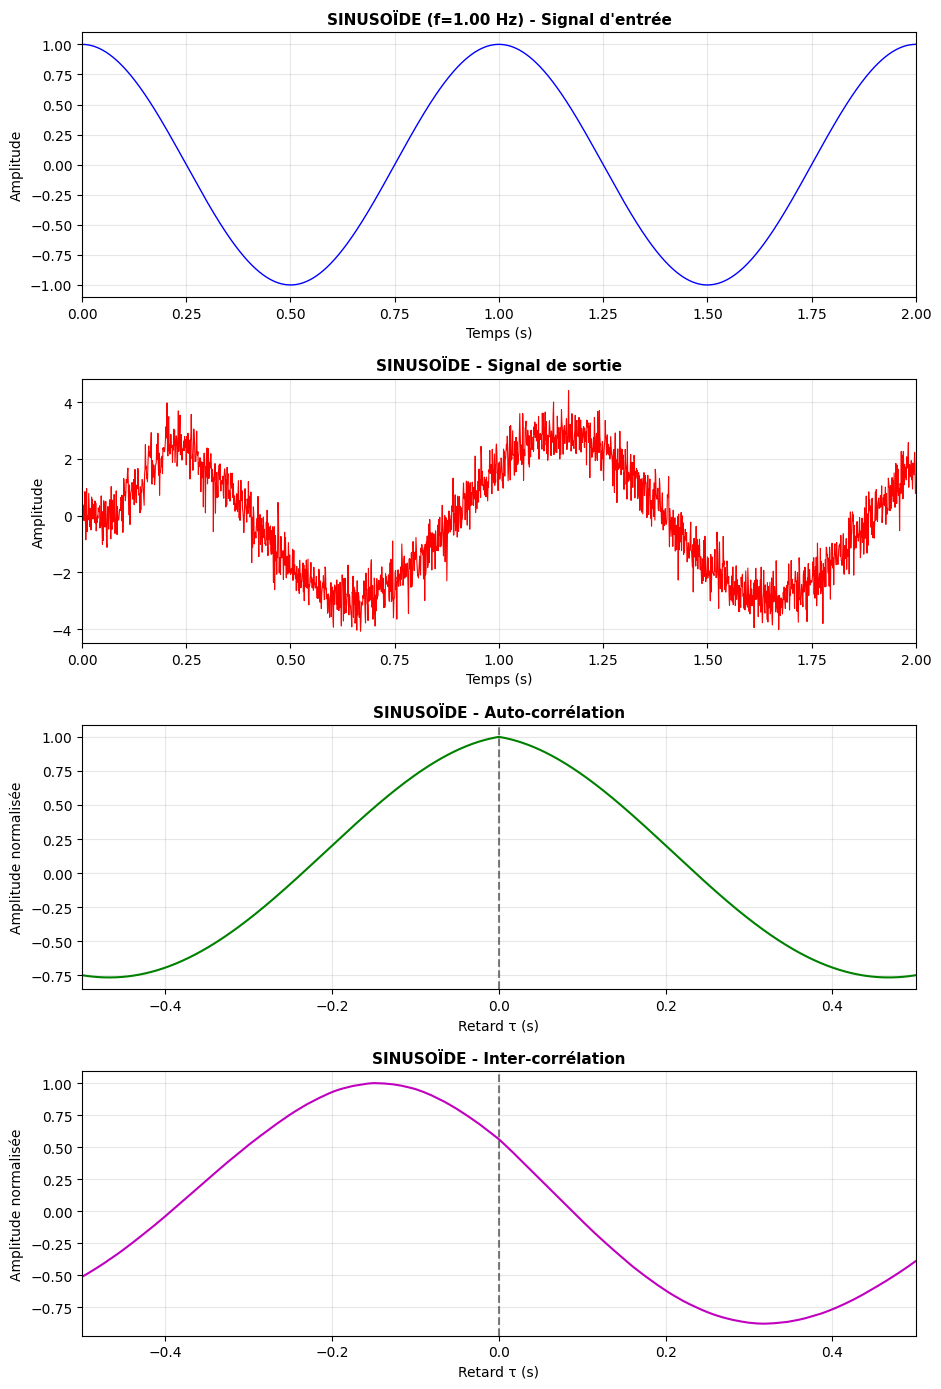

In [38]:
# Écrire votre code ici pour d)

# Signal sinusoidal
f_sin = w0 / (2*np.pi)  # 1 Hz
sin_input = np.cos(2 * np.pi * f_sin * t)

# Injecter dans la boîte noire
sin_output = blackbox_tp4.blackbox1(sin_input)

# AUTO-CORRÉLATION du signal sinusoidal
Rxx = np.correlate(sin_input, sin_input, mode='full')
Rxx_normalized = Rxx / np.max(np.abs(Rxx))

#INTER-CORRÉLATION entre le signal d'entrée et la sortie
Rxy = np.correlate(sin_input, sin_output, mode='full')
Rxy_normalized = Rxy / np.max(np.abs(Rxy))

dt = 1/fs
lags_xx = np.arange(-len(sin_input)+1, len(sin_input)) * dt  # Pour auto-corrélation
lags_xy = np.arange(-len(sin_input)+1, len(sin_output)) * dt  # Pour inter-corrélation

fig = plt.figure(figsize=(18, 14))

# Signal sinusoidal d'entrée
plt.subplot(4, 2, 2)
plt.plot(t, sin_input, 'b-', linewidth=1)
plt.title(f"SINUSOÏDE (f={f_sin:.2f} Hz) - Signal d'entrée", fontsize=11, fontweight='bold')
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.xlim([0, 2])

# Signal sinusoïdal de sortie
plt.subplot(4, 2, 4)
plt.plot(t, sin_output, 'r-', linewidth=0.8)
plt.title("SINUSOÏDE - Signal de sortie", fontsize=11, fontweight='bold')
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.xlim([0, 2])

# Auto-corrélation sinusoïde
plt.subplot(4, 2, 6)
plt.plot(lags_xx, Rxx_normalized, 'g-', linewidth=1.5)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.title("SINUSOÏDE - Auto-corrélation", fontsize=11, fontweight='bold')
plt.xlabel("Retard τ (s)")
plt.ylabel("Amplitude normalisée")
plt.grid(True, alpha=0.3)
plt.xlim([-0.5, 0.5])

# Inter-corrélation sinusoïde
plt.subplot(4, 2, 8)
plt.plot(lags_xy, Rxy_normalized, 'm-', linewidth=1.5)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.title("SINUSOÏDE - Inter-corrélation", fontsize=11, fontweight='bold')
plt.xlabel("Retard τ (s)")
plt.ylabel("Amplitude normalisée")
plt.grid(True, alpha=0.3)
plt.xlim([-0.5, 0.5])

plt.tight_layout()
plt.show()




**Interpretation**
Avec le chirp, nous pouvons distinguer 3 pics distinct (cibles), cependant, avec le signal sinusoidale, les pics sont ambigue et il est impossible de distinguer 2 cibles. (ou n'importe qu'elle évenements proche dans le temps). Le signal sinusoidale offre une mauvaise résolution temporelle, c'est pourquoi le signal chirp permet une meilleur analyse.

$\color{orange}{\text{e) [code]}}$  Déterminer la distance entre les cibles et le radar en considérant que l'unité de temps est donnée en microsecondes (ne pas oublier que le signal fait un aller-retour avec les cibles) $\color{red}{\textbf{(2pt/20)}}$



> **Note** : Nous supposons ici que le temps entre les maxima d'inter-corrélation correspond au délai réel entre les signaux. En temps normal, nous ne supposerions pas que le delai entre les maxima des deux interc-orrélations corresponde au délai exact, nous passerions par des tables qui associent pour notre système le délai d'intercorrélation au délai réel observé.


In [41]:
# Écrire votre code ici pour e)
def chirp_signal(w0, k, t, T):
    # Générer un signal chirp continu
    return np.cos(w0 * T * (k**(t/T)-1)/np.log2(k))

# Paramètres du signal chirp
w0 = 2*np.pi  # Fréquence de départ du chirp (en Hz)
k = np.e  # Taux de variation de la fréquence
T = 1  # Temps où f_T = k*f_0 (en secondes)

# Fréquence d'échantillonnage
fs = 1000  # Hz
tf = 2 # Durée du signal
t = np.arange(0, tf, 1/fs)

# Générer un signal chirp continu
chirp_input = chirp_signal(f0, f1, t, T)

chirp_output = blackbox_tp4.blackbox1(chirp_input)

#INTER-CORRÉLATION entre le signal d'entrée et la sortie
Rxy = np.correlate(chirp_input, chirp_output, mode='full')
Rxy_normalized = Rxy / np.max(np.abs(Rxy))

dt = 1/fs
lags_xy = np.arange(-len(sin_input)+1, len(sin_output)) * dt  # Pour inter-corrélation

# Trouver tous les pics (cibles)
peaks, properties = find_peaks(Rxy_normalized, height=0.3, distance=50)

print(f"\nNombre de cibles détectées : {len(peaks)}")
print("\nPositions des pics d'inter-corrélation :")
for i, peak_idx in enumerate(peaks):
    peak_lag = lags[peak_idx]
    amplitude = Rxy_normalized[peak_idx]
    print(f"  Cible {i+1}: τ = {peak_lag:.6f} s, amplitude = {amplitude:.3f}")

# Conversion en microseconde et distance
c = 3e8  # Vitesse de la lumière dans l'air (m/s)
c_per_us = c * 1e-6  # Vitesse en mètres par microseconde = 300 m/μs

for i, peak_idx in enumerate(peaks):
    peak_lag_seconds = lags[peak_idx]

    delai_us = abs(peak_lag_seconds)

    distance_m = (delai_us * c_per_us) / 2

    print(f"\nCible {i+1} :")
    print(f"  Délai mesuré        : τ = {peak_lag_seconds:.6f}")
    print(f"  Délai interprété    : {delai_us:.6f} μs ")
    print(f"  Distance calculée   : {distance_m:.2f} m")



Nombre de cibles détectées : 3

Positions des pics d'inter-corrélation :
  Cible 1: τ = -0.200000 s, amplitude = 0.910
  Cible 2: τ = -0.150000 s, amplitude = 1.000
  Cible 3: τ = -0.100000 s, amplitude = 0.935

Cible 1 :
  Délai mesuré        : τ = -0.200000
  Délai interprété    : 0.200000 μs 
  Distance calculée   : 30.00 m

Cible 2 :
  Délai mesuré        : τ = -0.150000
  Délai interprété    : 0.150000 μs 
  Distance calculée   : 22.50 m

Cible 3 :
  Délai mesuré        : τ = -0.100000
  Délai interprété    : 0.100000 μs 
  Distance calculée   : 15.00 m


## $\color{#03fc9d}{\textbf{Précisions pour la remise:}}$

* Pour chaque exercice, répondre en ajoutant des cases de code ou de texte en dessous de la question.

* Remettez sur moodle un fichier `.ipynb` ainsi qu'une version `pdf` contenant seulement l'exercice 3) avec toutes les librairies et importations nécessaires pour que le code roule.

* Indiquer noms, matricules et numéro d'équipe au début du `notebook`.